In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# here 
# AT= temperature
# V = vacuum
# AP = pressure
# RH = humidity
# target is PE= produced energy

In [5]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
x_train_tensor= torch.tensor(x_train_scaled, dtype = torch.float32)
x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [9]:
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [34]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False)

# building ANN model using deep learning

In [35]:
class ANN_model(nn.Module):
    def __init__(self):
        super(ANN_model, self).__init__()
        
        self.model = nn.Sequential(
        # 1st hidden layer
        nn.Linear(x_train.shape[1], 6),
        nn.ReLU(),

        # 2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        # output layer

        nn.Linear(6,1)
        )

    def forward(self, x):
        return self.model(x)

In [36]:
model = ANN_model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [40]:
# train the ANN model

train_losses = []
validation_losses = []

best_validation_losses = float("inf")

epochs = 100

for epoch in range(epochs):

    running_loss = 0.0
    model.train()

    for xb, yb in train_loader: # xb= feature of batch 1 yb label of batch 1
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() # loss is a tensor => py float

    each_epoch_loss = running_loss/len(train_loader)

    train_losses.append(each_epoch_loss)
    


    # model validation

    model.eval()

    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            output = model(xb)
            loss = criterion(output, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/ len(test_loader)
    validation_losses.append(epoch_val_loss)


    print(f"Epoch {epoch} of {epochs} training loss= {each_epoch_loss} validation loss = {epoch_val_loss} ")


    if epoch_val_loss < best_validation_losses:
        best_validation_losses = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth") #.pt or .pth
    

Epoch 0 of 100 training loss= 20.180036441485086 validation loss = 18.35175631841024 
Epoch 1 of 100 training loss= 20.172367974122366 validation loss = 18.28409916559855 
Epoch 2 of 100 training loss= 20.21012056271235 validation loss = 18.893294477462767 
Epoch 3 of 100 training loss= 20.00809972087542 validation loss = 18.22779959042867 
Epoch 4 of 100 training loss= 20.156744440396626 validation loss = 18.917452971140545 
Epoch 5 of 100 training loss= 20.419575170675913 validation loss = 18.149514961242676 
Epoch 6 of 100 training loss= 20.232114483912785 validation loss = 19.189016898473103 
Epoch 7 of 100 training loss= 20.045771888891856 validation loss = 18.201081562042237 
Epoch 8 of 100 training loss= 20.155489766597746 validation loss = 18.11426260471344 
Epoch 9 of 100 training loss= 20.088488813241323 validation loss = 18.632586606343587 
Epoch 10 of 100 training loss= 20.045490568876268 validation loss = 18.439481830596925 
Epoch 11 of 100 training loss= 19.97135490775108

In [38]:
# plotting the losses on the plot


import matplotlib.pyplot as plt

loss_df = pd.DataFrame({

    "training loss" : train_losses,
    "validation loss":validation_losses
})



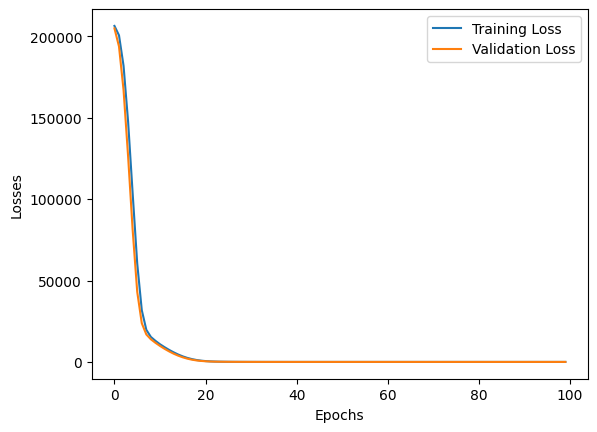

In [39]:
plt.plot(loss_df["training loss"], label = "Training Loss")
plt.plot(loss_df["validation loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [42]:
# loading the model

model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [45]:
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 19.383403778076172
Testing MSE: 17.712007522583008


In [46]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9381011064282746
